In [2]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import plotly.express as px

from prophet import Prophet

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("/content/hospital_dataset (1).csv")

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage
0,2022-01-01,Emergency,94,94,50,29,250,195,15,47,6,62,74.67
1,2022-01-01,Cardiology,50,12,50,17,250,96,8,25,4,33,37.67
2,2022-01-01,Neurology,51,13,50,20,250,109,8,25,4,33,43.00
3,2022-01-01,Orthopedics,59,18,50,18,250,121,9,29,5,38,46.33
4,2022-01-01,Pediatrics,59,19,50,20,250,116,9,29,4,38,45.33


In [11]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6576 entries, 0 to 6575
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      6576 non-null   object 
 1   Department                6576 non-null   object 
 2   Admissions                6576 non-null   int64  
 3   Emergency_Cases           6576 non-null   int64  
 4   ICU_Beds_Total            6576 non-null   int64  
 5   ICU_Beds_Occupied         6576 non-null   int64  
 6   General_Beds_Total        6576 non-null   int64  
 7   General_Beds_Occupied     6576 non-null   int64  
 8   Doctors_On_Duty           6576 non-null   int64  
 9   Nurses_On_Duty            6576 non-null   int64  
 10  Ambulances_Available      6576 non-null   int64  
 11  Staff_Required            6576 non-null   int64  
 12  Bed_Occupancy_Percentage  6576 non-null   float64
dtypes: float64(1), int64(10), object(2)
memory usage: 668.0+ KB
Non

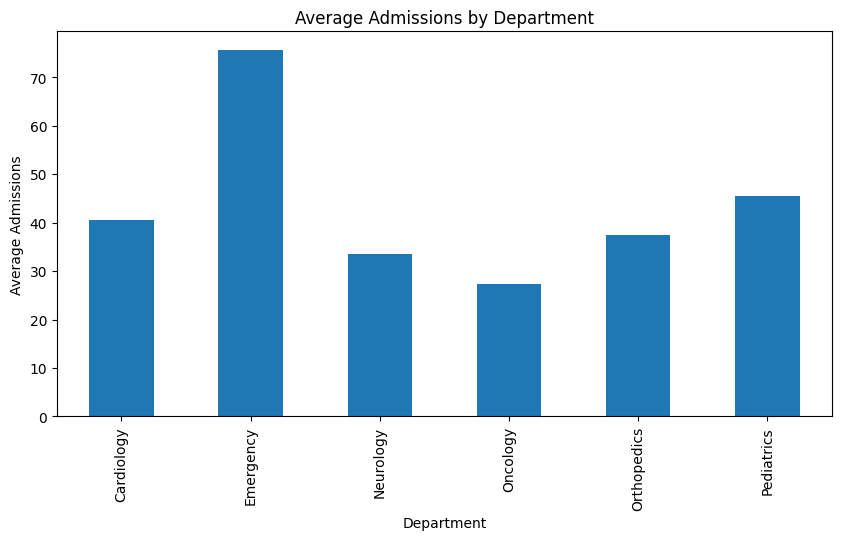

In [12]:
plt.figure(figsize=(10,5))

df.groupby("Department")["Admissions"].mean().plot(kind="bar")

plt.title("Average Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Average Admissions")

plt.show()

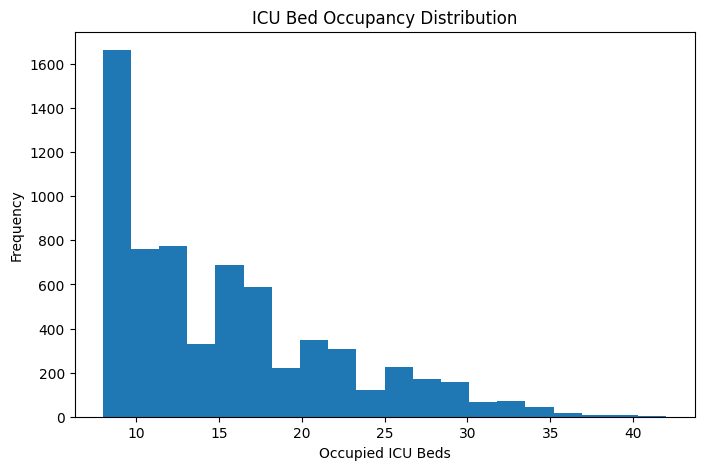

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["ICU_Beds_Occupied"], bins=20)

plt.title("ICU Bed Occupancy Distribution")
plt.xlabel("Occupied ICU Beds")
plt.ylabel("Frequency")

plt.show()

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage
0,2022-01-01,Emergency,94,94,50,29,250,195,15,47,6,62,74.67
1,2022-01-01,Cardiology,50,12,50,17,250,96,8,25,4,33,37.67
2,2022-01-01,Neurology,51,13,50,20,250,109,8,25,4,33,43.00
3,2022-01-01,Orthopedics,59,18,50,18,250,121,9,29,5,38,46.33
4,2022-01-01,Pediatrics,59,19,50,20,250,116,9,29,4,38,45.33


In [15]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,Emergency,94,94,50,29,250,195,15,47,6,62,74.67,2022,1,1,5,52
1,2022-01-01,Cardiology,50,12,50,17,250,96,8,25,4,33,37.67,2022,1,1,5,52
2,2022-01-01,Neurology,51,13,50,20,250,109,8,25,4,33,43.00,2022,1,1,5,52
3,2022-01-01,Orthopedics,59,18,50,18,250,121,9,29,5,38,46.33,2022,1,1,5,52
4,2022-01-01,Pediatrics,59,19,50,20,250,116,9,29,4,38,45.33,2022,1,1,5,52


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Department"] = encoder.fit_transform(df["Department"])

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,1,94,94,50,29,250,195,15,47,6,62,74.67,2022,1,1,5,52
1,2022-01-01,0,50,12,50,17,250,96,8,25,4,33,37.67,2022,1,1,5,52
2,2022-01-01,2,51,13,50,20,250,109,8,25,4,33,43.00,2022,1,1,5,52
3,2022-01-01,4,59,18,50,18,250,121,9,29,5,38,46.33,2022,1,1,5,52
4,2022-01-01,5,59,19,50,20,250,116,9,29,4,38,45.33,2022,1,1,5,52


In [17]:

features = [
    "Department",
    "Admissions",
    "Emergency_Cases",
    "ICU_Beds_Occupied",
    "General_Beds_Occupied",
    "Doctors_On_Duty",
    "Nurses_On_Duty",
    "Ambulances_Available"
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,0.2,0.847619,0.851852,50,0.617647,250,0.815603,0.769231,0.80,1.0,62,74.67,2022,1,1,5,52
1,2022-01-01,0.0,0.428571,0.092593,50,0.264706,250,0.113475,0.230769,0.25,0.0,33,37.67,2022,1,1,5,52
2,2022-01-01,0.4,0.438095,0.101852,50,0.352941,250,0.205674,0.230769,0.25,0.0,33,43.00,2022,1,1,5,52
3,2022-01-01,0.8,0.514286,0.148148,50,0.294118,250,0.290780,0.307692,0.35,0.5,38,46.33,2022,1,1,5,52
4,2022-01-01,1.0,0.514286,0.157407,50,0.352941,250,0.255319,0.307692,0.35,0.0,38,45.33,2022,1,1,5,52


In [19]:
prophet_df = pd.read_csv("/content/hospital_dataset (1).csv")

prophet_df["Date"] = pd.to_datetime(prophet_df["Date"])

prophet_df = prophet_df.groupby("Date")["Admissions"].sum().reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2022-01-01,363
1,2022-01-02,383
2,2022-01-03,306
3,2022-01-04,310
4,2022-01-05,323


In [20]:


model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(prophet_df)

In [21]:
future = model.make_future_dataframe(periods=7)

forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(7)

,ds,yhat,yhat_lower,yhat_upper
1096,2025-01-01,312.402101,295.451617,329.319013
1097,2025-01-02,316.397407,300.676620,332.980277
1098,2025-01-03,315.547006,298.187820,333.139143
1099,2025-01-04,364.687753,348.668851,380.944717
1100,2025-01-05,366.600211,350.605133,383.694665
1101,2025-01-06,320.977312,304.516898,337.047319
1102,2025-01-07,322.268749,305.457930,339.364868


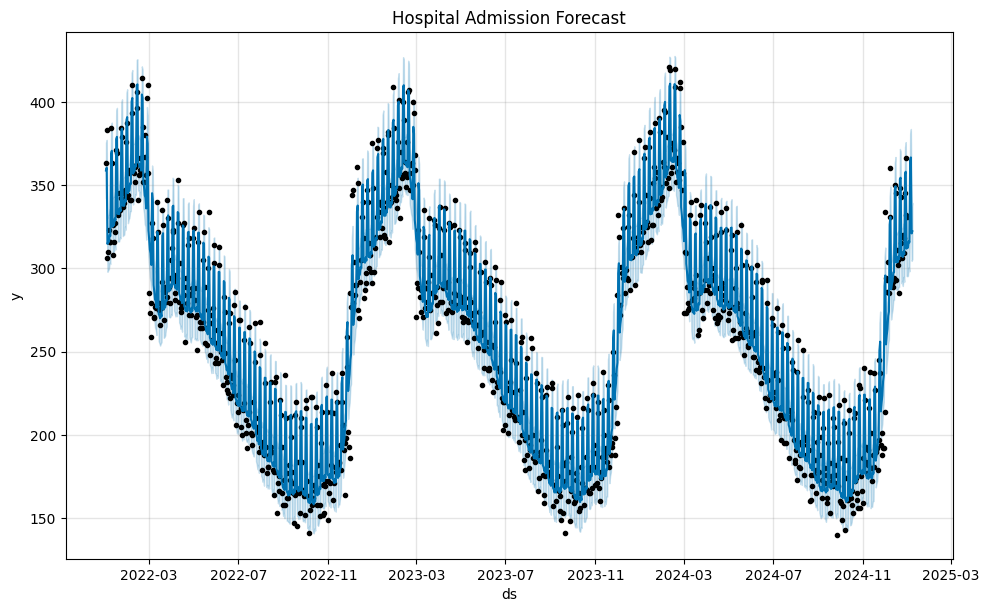

In [22]:
model.plot(forecast)

plt.title("Hospital Admission Forecast")

plt.show()

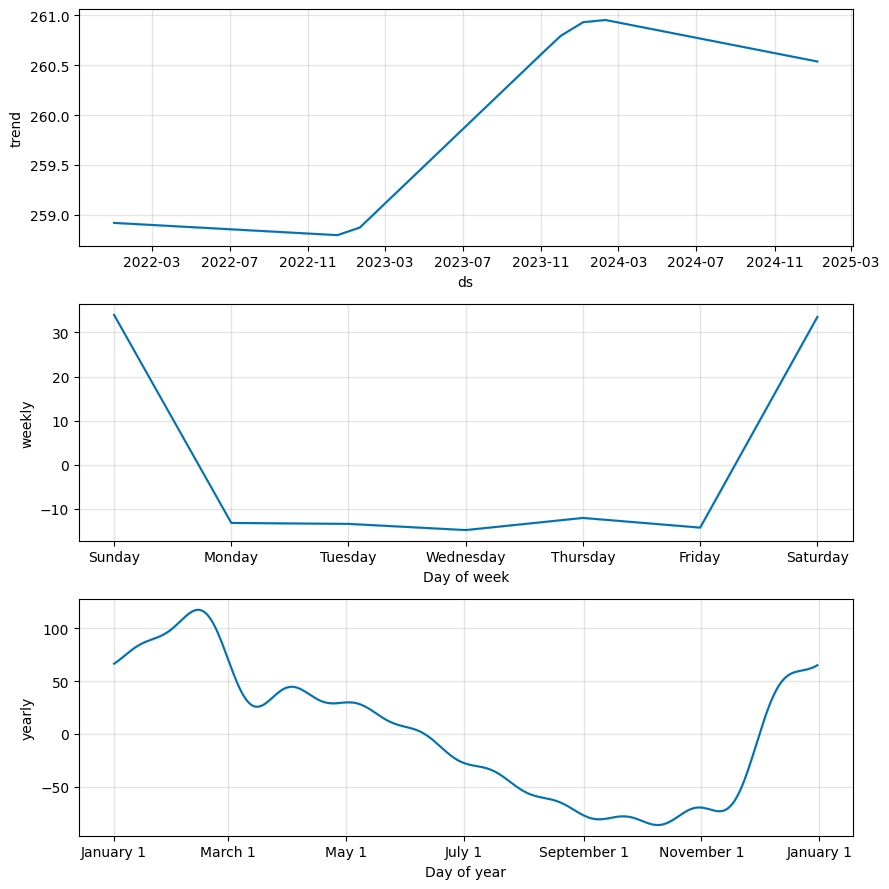

In [23]:
model.plot_components(forecast)

plt.show()

In [24]:

# Load original dataset
lstm_df = pd.read_csv("/content/hospital_dataset (1).csv")

# Convert Date
lstm_df["Date"] = pd.to_datetime(lstm_df["Date"])

# Aggregate daily ICU occupancy
daily_icu = lstm_df.groupby("Date")["ICU_Beds_Occupied"].sum().reset_index()

daily_icu.head()

,Date,ICU_Beds_Occupied
0,2022-01-01,120
1,2022-01-02,134
2,2022-01-03,96
3,2022-01-04,98
4,2022-01-05,113


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(daily_icu[["ICU_Beds_Occupied"]])

scaled_data[:5]

array([[0.63366337],
       [0.77227723],
       [0.3960396 ],
       [0.41584158],
       [0.56435644]])

In [26]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1066, 30, 1)
y Shape: (1066,)


In [27]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(852, 30, 1)
(214, 30, 1)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64,
               return_sequences=True,
               input_shape=(30,1)))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0461 - val_loss: 0.0146
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0172 - val_loss: 0.0109
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0153 - val_loss: 0.0105
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0145 - val_loss: 0.0102
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0153 - val_loss: 0.0100
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0140 - val_loss: 0.0101
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0148 - val_loss: 0.0102
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0145 - val_loss: 0.0098
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0144 - val_loss: 0.0096
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0144 - val_loss: 0.0097
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0146 - val_loss: 0.0095
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0

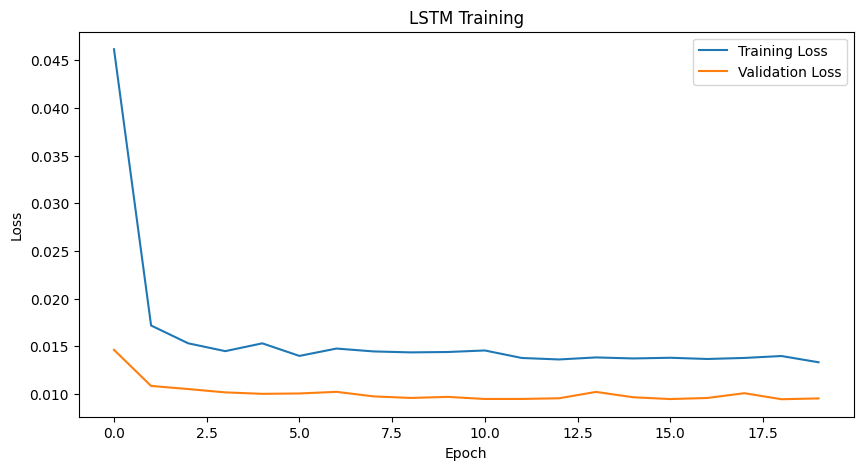

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [31]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


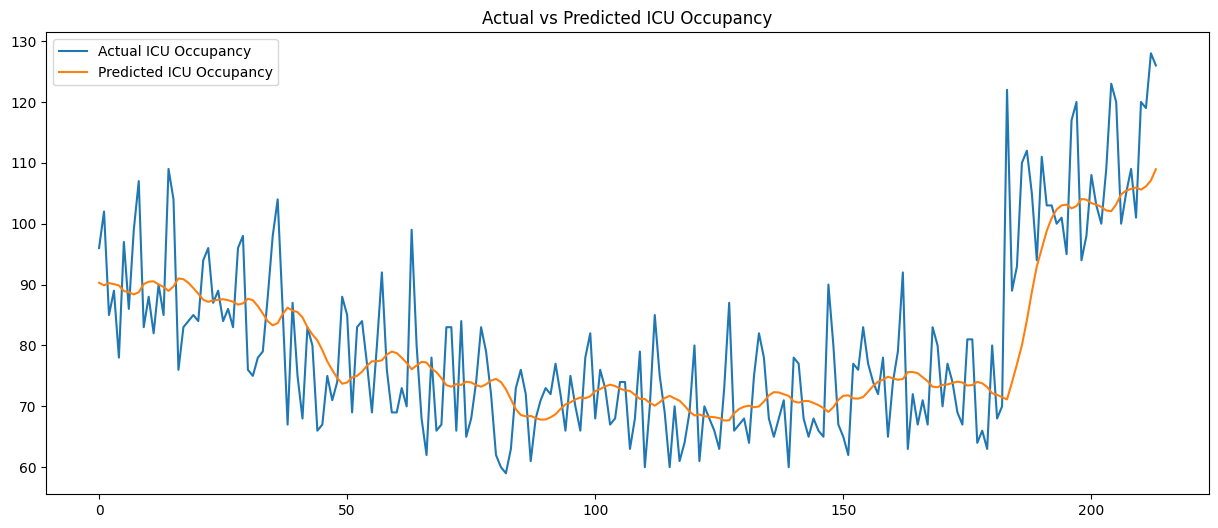

In [32]:
plt.figure(figsize=(15,6))

plt.plot(actual, label="Actual ICU Occupancy")

plt.plot(predictions, label="Predicted ICU Occupancy")

plt.legend()

plt.title("Actual vs Predicted ICU Occupancy")

plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 7.6
RMSE: 9.87


In [34]:
last_sequence = scaled_data[-30:]
current_sequence = last_sequence.copy()

future_predictions = []

for _ in range(7):
    pred = model.predict(
        current_sequence.reshape(1,30,1),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    current_sequence = np.append(
        current_sequence[1:],
        pred,
        axis=0
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Predicted ICU Occupancy for Next 7 Days:\n")

for i,value in enumerate(future_predictions,1):
    print(f"Day {i}: {int(value[0])} beds occupied")

Predicted ICU Occupancy for Next 7 Days:

Day 1: 111 beds occupied
Day 2: 112 beds occupied
Day 3: 112 beds occupied
Day 4: 112 beds occupied
Day 5: 112 beds occupied
Day 6: 112 beds occupied
Day 7: 111 beds occupied


In [35]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Department"] = encoder.fit_transform(df["Department"])

df.head()

,Date,Department,Admissions,Emergency_Cases,ICU_Beds_Total,ICU_Beds_Occupied,General_Beds_Total,General_Beds_Occupied,Doctors_On_Duty,Nurses_On_Duty,Ambulances_Available,Staff_Required,Bed_Occupancy_Percentage,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,1,0.847619,0.851852,50,0.617647,250,0.815603,0.769231,0.80,1.0,62,74.67,2022,1,1,5,52
1,2022-01-01,0,0.428571,0.092593,50,0.264706,250,0.113475,0.230769,0.25,0.0,33,37.67,2022,1,1,5,52
2,2022-01-01,2,0.438095,0.101852,50,0.352941,250,0.205674,0.230769,0.25,0.0,33,43.00,2022,1,1,5,52
3,2022-01-01,4,0.514286,0.148148,50,0.294118,250,0.290780,0.307692,0.35,0.5,38,46.33,2022,1,1,5,52
4,2022-01-01,5,0.514286,0.157407,50,0.352941,250,0.255319,0.307692,0.35,0.0,38,45.33,2022,1,1,5,52


In [36]:
X = df[
    [
        "Department",
        "Admissions",
        "Emergency_Cases",
        "ICU_Beds_Occupied",
        "General_Beds_Occupied"
    ]
]

y_doctor = df["Doctors_On_Duty"]

y_nurse = df["Nurses_On_Duty"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_doc_train, y_doc_test = train_test_split(
    X,
    y_doctor,
    test_size=0.2,
    random_state=42
)

_, _, y_nurse_train, y_nurse_test = train_test_split(
    X,
    y_nurse,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestRegressor

doctor_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

doctor_model.fit(
    X_train,
    y_doc_train
)

RandomForestRegressor(random_state=42)

In [39]:
nurse_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

nurse_model.fit(
    X_train,
    y_nurse_train
)

RandomForestRegressor(random_state=42)

In [40]:
doctor_prediction = doctor_model.predict(X_test)

nurse_prediction = nurse_model.predict(X_test)

In [41]:

doctor_mae = mean_absolute_error(
    y_doc_test,
    doctor_prediction
)

nurse_mae = mean_absolute_error(
    y_nurse_test,
    nurse_prediction
)

print("Doctor Prediction MAE :", doctor_mae)

print("Nurse Prediction MAE :", nurse_mae)

Doctor Prediction MAE : 2.922609306021183e-06
Nurse Prediction MAE : 9.118541033647049e-06


In [44]:
from sklearn.preprocessing import LabelEncoder

# Reload the original dataset
temp_df = pd.read_csv("/content/hospital_dataset (1).csv")

encoder = LabelEncoder()
encoder.fit(temp_df["Department"])

print(encoder.classes_)

['Cardiology' 'Emergency' 'Neurology' 'Oncology' 'Orthopedics'
 'Pediatrics']


In [45]:
sample = [[
    encoder.transform(["Emergency"])[0],
    95,
    40,
    38,
    210
]]

doctor_needed = doctor_model.predict(sample)

nurse_needed = nurse_model.predict(sample)

print("Doctors Needed :", round(doctor_needed[0]))

print("Nurses Needed :", round(nurse_needed[0]))

Doctors Needed : 1
Nurses Needed : 1


In [46]:
print("="*50)

print("RESOURCE RECOMMENDATION")

print("="*50)

print(f"Doctors Required : {round(doctor_needed[0])}")

print(f"Nurses Required : {round(nurse_needed[0])}")

if doctor_needed[0] > 15:
    print("\nIncrease Doctor Shift")

if nurse_needed[0] > 35:
    print("Increase Nursing Staff")

print("="*50)

RESOURCE RECOMMENDATION
Doctors Required : 1
Nurses Required : 1


In [47]:
import pandas as pd

hospital_data = {
    "Hospital_Name": [
        "CityCare General Hospital",
        "Apollo Hospital",
        "Fortis Hospital",
        "AIIMS",
        "Medanta Hospital"
    ],

    "Distance_km":[
        2.5,
        5.8,
        7.2,
        3.9,
        10.1
    ],

    "ICU_Beds_Available":[
        4,
        12,
        0,
        8,
        15
    ],

    "General_Beds_Available":[
        25,
        40,
        8,
        35,
        60
    ],

    "Ambulances_Available":[
        2,
        5,
        1,
        3,
        4
    ],

    "Department":[
        "Emergency",
        "Cardiology",
        "Emergency",
        "Neurology",
        "Orthopedics"
    ]
}

hospital_df = pd.DataFrame(hospital_data)

hospital_df

,Hospital_Name,Distance_km,ICU_Beds_Available,General_Beds_Available,Ambulances_Available,Department
0,CityCare General Hospital,2.5,4,25,2,Emergency
1,Apollo Hospital,5.8,12,40,5,Cardiology
2,Fortis Hospital,7.2,0,8,1,Emergency
3,AIIMS,3.9,8,35,3,Neurology
4,Medanta Hospital,10.1,15,60,4,Orthopedics


In [48]:
hospital_df.to_csv("nearby_hospitals.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [49]:
required_department = "Emergency"

required_icu = 1

In [50]:
available = hospital_df[
    (hospital_df["Department"] == required_department) &
    (hospital_df["ICU_Beds_Available"] >= required_icu)
]

available

,Hospital_Name,Distance_km,ICU_Beds_Available,General_Beds_Available,Ambulances_Available,Department
0,CityCare General Hospital,2.5,4,25,2,Emergency


In [51]:
recommended = available.sort_values(
    by=["Distance_km","ICU_Beds_Available"],
    ascending=[True,False]
)

recommended

,Hospital_Name,Distance_km,ICU_Beds_Available,General_Beds_Available,Ambulances_Available,Department
0,CityCare General Hospital,2.5,4,25,2,Emergency


In [52]:
best = recommended.iloc[0]

print("="*50)

print("AMBULANCE ROUTING SYSTEM")

print("="*50)

print("Recommended Hospital")

print()

print("Hospital :", best["Hospital_Name"])

print("Distance :", best["Distance_km"],"km")

print("ICU Beds Available :", best["ICU_Beds_Available"])

print("General Beds :", best["General_Beds_Available"])

print("Ambulances :", best["Ambulances_Available"])

print("="*50)

AMBULANCE ROUTING SYSTEM
Recommended Hospital

Hospital : CityCare General Hospital
Distance : 2.5 km
ICU Beds Available : 4
General Beds : 25
Ambulances : 2


In [53]:
hospital_df.sort_values("Distance_km")

,Hospital_Name,Distance_km,ICU_Beds_Available,General_Beds_Available,Ambulances_Available,Department
0,CityCare General Hospital,2.5,4,25,2,Emergency
3,AIIMS,3.9,8,35,3,Neurology
1,Apollo Hospital,5.8,12,40,5,Cardiology
2,Fortis Hospital,7.2,0,8,1,Emergency
4,Medanta Hospital,10.1,15,60,4,Orthopedics


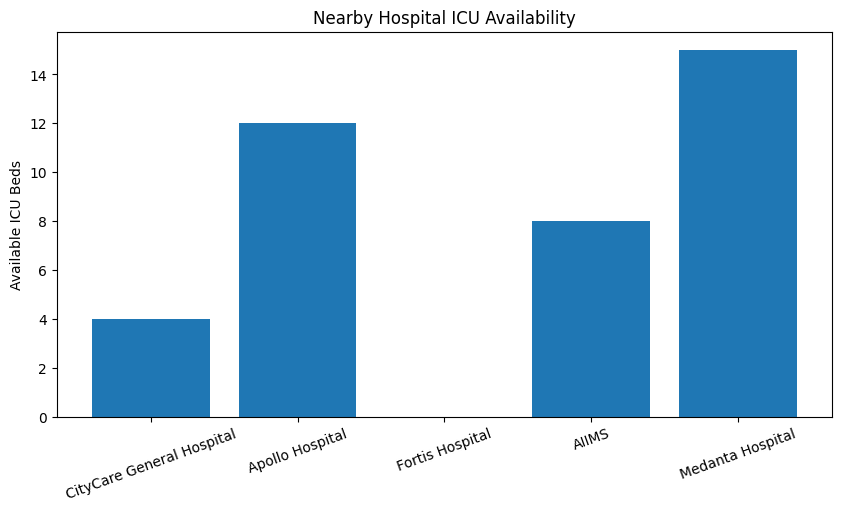

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    hospital_df["Hospital_Name"],
    hospital_df["ICU_Beds_Available"]
)

plt.xticks(rotation=20)

plt.ylabel("Available ICU Beds")

plt.title("Nearby Hospital ICU Availability")

plt.show()

In [56]:
def recommend_hospital(department, icu_needed=1):

    available = hospital_df[
        (hospital_df["Department"] == department) &
        (hospital_df["ICU_Beds_Available"] >= icu_needed)
    ]

    if available.empty:
        print("❌ No hospital available.")
        return

    best = available.sort_values(
        by=["Distance_km", "ICU_Beds_Available"],
        ascending=[True, False]
    ).iloc[0]

    print("🚑 Recommended Hospital")
    print("----------------------")
    print("Hospital :", best["Hospital_Name"])
    print("Distance :", best["Distance_km"], "km")
    print("ICU Beds :", best["ICU_Beds_Available"])
    print("Department :", best["Department"])

In [58]:
recommend_hospital("Cardiology")
recommend_hospital("Neurology")
recommend_hospital("Orthopedics")

🚑 Recommended Hospital
----------------------
Hospital : Apollo Hospital
Distance : 5.8 km
ICU Beds : 12
Department : Cardiology
🚑 Recommended Hospital
----------------------
Hospital : AIIMS
Distance : 3.9 km
ICU Beds : 8
Department : Neurology
🚑 Recommended Hospital
----------------------
Hospital : Medanta Hospital
Distance : 10.1 km
ICU Beds : 15
Department : Orthopedics
